#### Importing all libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.model_selection import  train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler

from catboost import CatBoostRegressor

#### Load the dataset

In [2]:
df = pd.read_csv('data.csv')
df.head()

,invoice_id,customer_id,transaction_date,product_id,quantity,unit_price,total,discount_rate,refund_flag,payment_method,country
0,INV0079407,C02045,2023-01-01,P048,2,8584,17168,0.14,0,Card,Germany
1,INV0581190,C14584,2023-01-01,P090,4,7779,31118,0.16,0,Card,UK
2,INV0410888,C10301,2023-01-01,P043,5,6183,30913,0.32,0,Card,US
3,INV0429115,C10733,2023-01-01,P085,5,14,68,0.39,0,Card,India
4,INV0020948,C00558,2023-01-01,P006,5,15309,76547,0.24,0,UPI,US


#### Performing EDA

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 793351 entries, 0 to 793350
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   invoice_id        793351 non-null  object 
 1   customer_id       793351 non-null  object 
 2   transaction_date  793351 non-null  object 
 3   product_id        793351 non-null  object 
 4   quantity          793351 non-null  int64  
 5   unit_price        793351 non-null  int64  
 6   total             793351 non-null  int64  
 7   discount_rate     793351 non-null  float64
 8   refund_flag       793351 non-null  int64  
 9   payment_method    793351 non-null  object 
 10  country           793351 non-null  object 
dtypes: float64(1), int64(4), object(6)
memory usage: 66.6+ MB


In [4]:
df.describe()

,quantity,unit_price,total,discount_rate,refund_flag
count,793351.000000,793351.000000,793351.000000,793351.000000,793351.000000
mean,3.001179,6321.968230,18964.420942,0.200107,0.055127
std,1.414622,5367.747432,19925.866928,0.115571,0.228228
min,1.000000,5.000000,5.000000,0.000000,0.000000
25%,2.000000,1879.000000,4053.000000,0.100000,0.000000
50%,3.000000,5162.000000,12487.000000,0.200000,0.000000
75%,4.000000,9683.000000,27613.000000,0.300000,0.000000
max,5.000000,21000.000000,105000.000000,0.400000,1.000000


# Step 2 - Clean the dataset
- convert the transaction_date column to Date

In [5]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

In [6]:
# Find duplicates

df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
793346    False
793347    False
793348    False
793349    False
793350    False
Length: 793351, dtype: bool

#### Creating Revenue column and removing the refund == 1

In [7]:
df['revenue'] = df['total'] * (1 - df['discount_rate'])         # Calculating revenue
df = df[df['refund_flag'] == 0]                                 # remove who returns 

# Step 3 - Basic Visualization
- In this we create daily, monthly revenue chart's

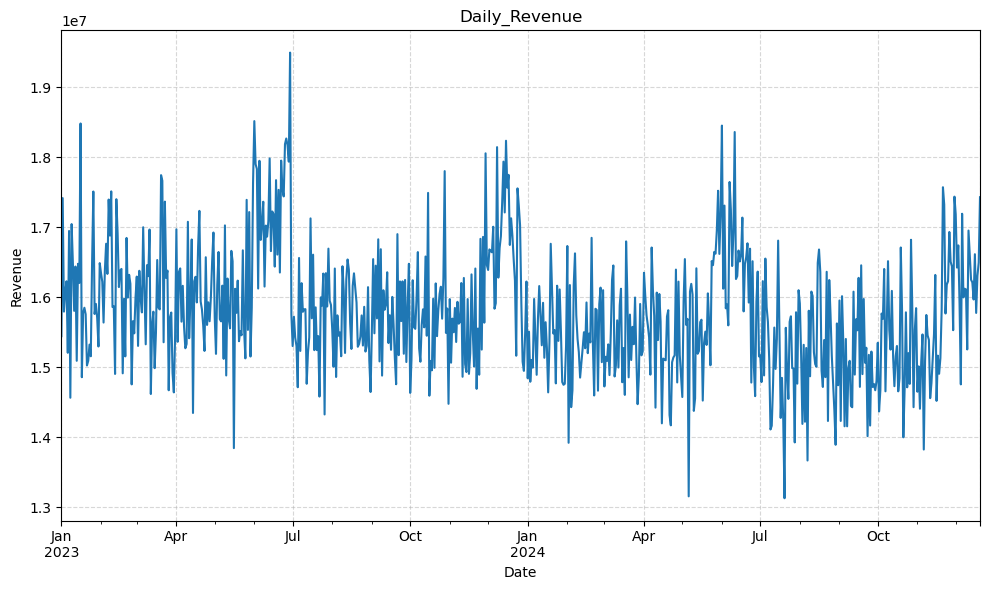

In [8]:
daily_revenue = df.resample('D', on='transaction_date')['revenue'].sum()

daily_revenue.plot(figsize=(10,6))
plt.title('Daily_Revenue')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

#### Monthly Revenue

C:\Users\Farhan Diwan\AppData\Local\Temp\ipykernel_2512\1277070108.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_revenue = df.resample('M', on='transaction_date')['revenue'].sum()


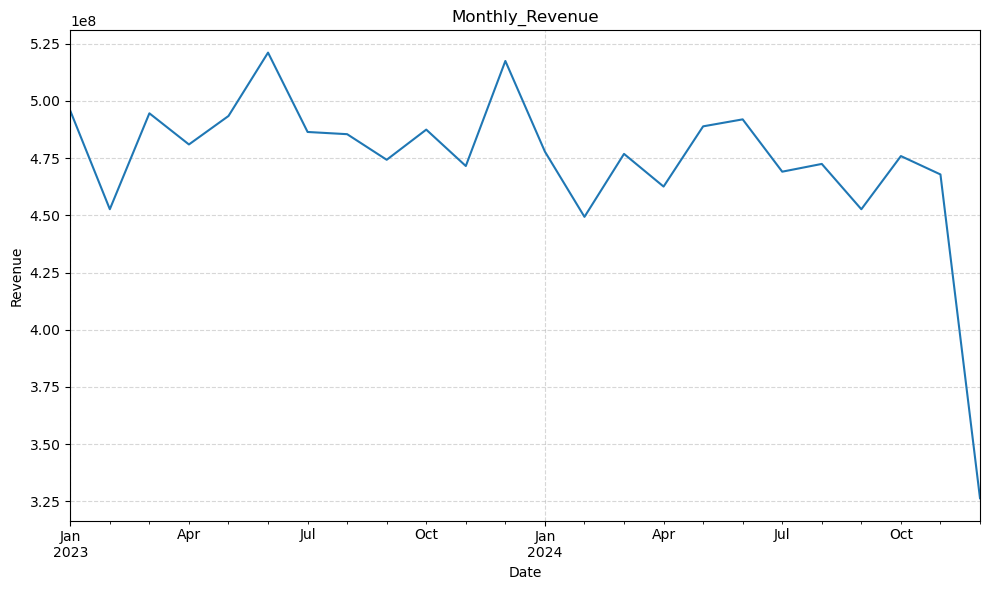

In [9]:
monthly_revenue = df.resample('M', on='transaction_date')['revenue'].sum()

monthly_revenue.plot(figsize=(10,6))
plt.title('Monthly_Revenue')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

#### Top customer's

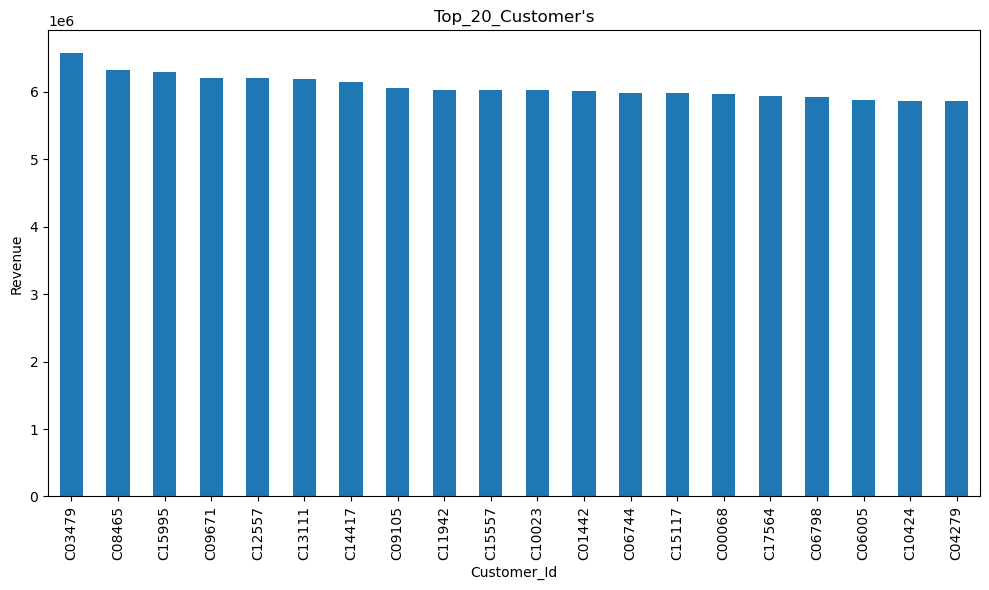

In [10]:
top_customers = df.groupby('customer_id')['revenue'].sum().nlargest(20)

top_customers.plot(kind='bar', figsize=(10,6))
plt.title("Top_20_Customer's")
plt.xlabel('Customer_Id')
plt.ylabel('Revenue')
plt.tight_layout()

#### Revenue by country 

In [11]:
# Customer who gives maximu revenue

top_1 = df.groupby('customer_id')['revenue'].sum()
top_1.sort_values(ascending=False).head(1)

customer_id
C03479    6584314.65
Name: revenue, dtype: float64

In [12]:
# Most common dicount rate

dis_rate = df['discount_rate'].mode()[0]    # mode is FUNC..... which count items how many times in column
dis_rate

np.float64(0.33)

In [13]:
# Country who gives maximum revenue

top_1_country = df.groupby('country')['revenue'].sum()
top_1_country.idxmax()

'UK'

# Step 4 - Create time_series_split 
- In this we have 12 months so we seprate by date to 9M = Fetures | 3M = Labels
- For that first we have to sort the transaction date 
- after that we have to define the snapshot date

In [14]:
df = df.sort_values('transaction_date')

In [15]:
max_date = df['transaction_date'].max()
cut_off  = max_date - pd.DateOffset(months=3)          # DateOffset moves the date to 3 month

### Spliting the data 

In [16]:
past_data = df[df['transaction_date'] < cut_off]
future_data = df[df['transaction_date'] >= cut_off]

#### Now we have to calculate the RFM fetured Enginering but only on the past data

# Step 5 - Feature Engineering
- In this we calculate our fetures based on the data 

In [17]:
# Now we always have to group the customer_id so we create variable

group = past_data.groupby('customer_id')

#### Define snapshot_date
- imp for calculating RFM

In [18]:
snap_date = past_data['transaction_date'].max()
snap_date

Timestamp('2024-09-19 00:00:00')

### Recency = means gap between today and its last purchase 

In [19]:
recency = (snap_date - group['transaction_date'].max()).dt.days

In [20]:
recency.head()

customer_id
C00001    420
C00002     20
C00003     59
C00004    539
C00005     51
Name: transaction_date, dtype: int64

### Frequnecy - How many times each user buy

In [21]:
frequency = group['invoice_id'].nunique()

In [22]:
frequency.head()

customer_id
C00001     3
C00002    34
C00003     4
C00004     2
C00005     9
Name: invoice_id, dtype: int64

### Monetary value - total revenue genrated by each customer

In [23]:
monetary = group['revenue'].sum()

In [24]:
monetary.head()

customer_id
C00001     26120.41
C00002    122072.20
C00003      9363.40
C00004      3139.84
C00005     26944.34
Name: revenue, dtype: float64

### AOV(Average order value) - how much money user spend on 1 purchase

In [25]:
aov = monetary / frequency

In [26]:
aov.head()

customer_id
C00001    8706.803333
C00002    3590.358824
C00003    2340.850000
C00004    1569.920000
C00005    2993.815556
dtype: float64

### Tenure(last purchase - first)  = how many days it's active with us

In [27]:
tenure = (group['transaction_date'].max() - group['transaction_date'].min()).dt.days

In [28]:
tenure.head()

customer_id
C00001    182
C00002    599
C00003    288
C00004     66
C00005    446
Name: transaction_date, dtype: int64

### Revenue last 30 days

In [29]:
cutoff_30 = snap_date - pd.Timedelta(days=30)

revenue_last_30 = past_data[past_data['transaction_date'] > cutoff_30].groupby('customer_id')['revenue'].sum()
revenue_last_30.head()

customer_id
C00002       805.10
C00009     11543.25
C00010     53305.04
C00013      5779.88
C00014    206512.65
Name: revenue, dtype: float64

### Revenue last 90 days

In [30]:
cutoff_90 = snap_date - pd.Timedelta(days = 90)

revenue_last_90 = past_data[past_data['transaction_date'] > cutoff_90].groupby('customer_id')['revenue'].sum()
revenue_last_90.head()

customer_id
C00002     8220.64
C00003     2127.20
C00005      646.40
C00007    14529.19
C00009    27241.05
Name: revenue, dtype: float64

### Orders last 30 days

In [31]:
order_last_30 = past_data[past_data['transaction_date'] > cutoff_30].groupby('customer_id')['invoice_id'].nunique()
order_last_30.head()

customer_id
C00002    1
C00009    1
C00010    5
C00013    5
C00014    4
Name: invoice_id, dtype: int64

### Orders last 90 days

In [32]:
order_last_90 = past_data[past_data['transaction_date'] > cutoff_90].groupby('customer_id')['invoice_id'].nunique()
order_last_90.head()

customer_id
C00002    4
C00003    1
C00005    1
C00007    4
C00009    2
Name: invoice_id, dtype: int64

### Purchase velocity - in how many days its place new order

In [33]:
purchase_velocity = (frequency / tenure.replace(0,1)).round(4)
purchase_velocity.head()

customer_id
C00001    0.0165
C00002    0.0568
C00003    0.0139
C00004    0.0303
C00005    0.0202
dtype: float64

### Purchase Trend - rev30/rev90

In [34]:
purchase_trend = (revenue_last_30 / revenue_last_90.replace(0,1)).fillna(0)
purchase_trend.head()

customer_id
C00002    0.097936
C00003    0.000000
C00005    0.000000
C00007    0.000000
C00009    0.423745
Name: revenue, dtype: float64

### Mean discount - avg discount each customer got

In [35]:
mean_discount = (group['discount_rate'].mean()).fillna(0)
mean_discount.head()

customer_id
C00001    0.250000
C00002    0.215294
C00003    0.252500
C00004    0.375000
C00005    0.146667
Name: discount_rate, dtype: float64

## Creatig customer level dataframe
- we create this from this calculated columns
- this is our fetures

In [36]:
customer_df = pd.DataFrame({
    'recency': recency,
    'frequency': frequency,
    'monetary': monetary,
    'aov': aov,
    'tenure': tenure,
    'revenue_last_30_days': revenue_last_30,
    'revenue_last_90_days': revenue_last_90,
    'orders_last_30_days': order_last_30,
    'orders_last_90_days': order_last_90,
    'purchase_velocity': purchase_velocity,
    'purchase_trend': purchase_trend,
    'mean_discount': mean_discount
})
    

In [37]:
customer_df = customer_df.fillna(0)        # Filling Null values

In [38]:
customer_df.isnull().sum()                # Check for null values

recency                 0
frequency               0
monetary                0
aov                     0
tenure                  0
revenue_last_30_days    0
revenue_last_90_days    0
orders_last_30_days     0
orders_last_90_days     0
purchase_velocity       0
purchase_trend          0
mean_discount           0
dtype: int64

Text(0.5, 1.0, 'Feature Correlation Matrix')

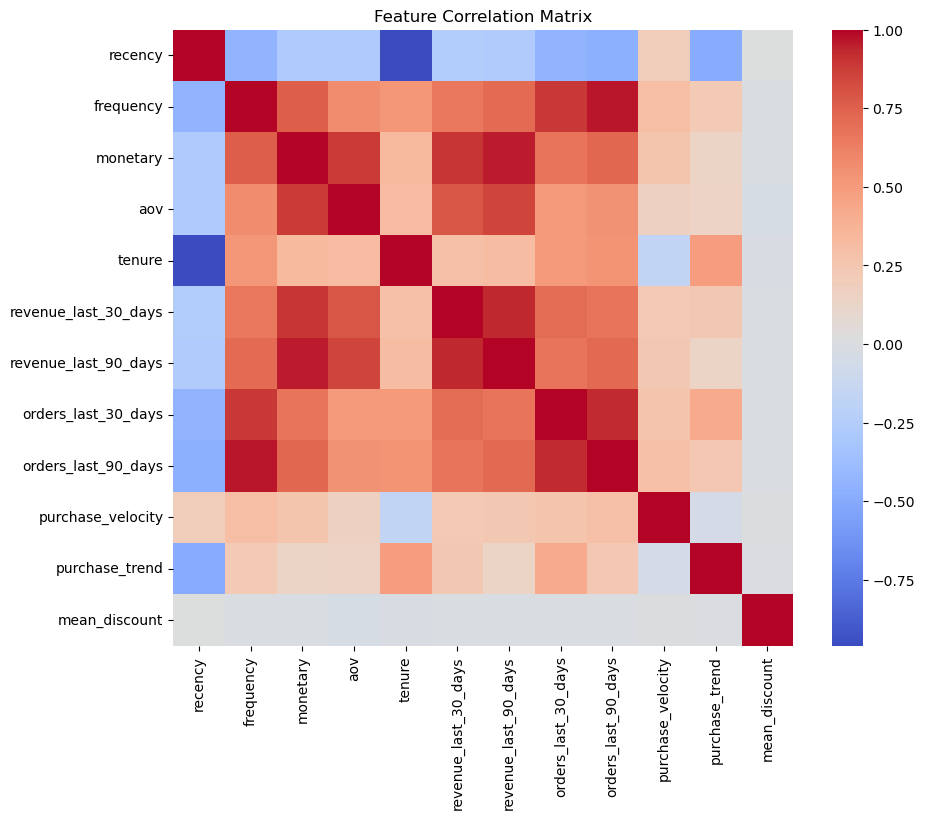

In [39]:
# Creating heatmap of Fetures Co-relation with each other 

plt.figure(figsize=(10,8))

sns.heatmap(
    customer_df.corr(numeric_only=True),
    annot=False,
    cmap="coolwarm")

plt.title("Feature Correlation Matrix")

# Step 6 - Creating Future revenue

In [40]:
# Here we creaet a future revnue from the future data which is our LABEL's

future_revenue = future_data.groupby('customer_id')['revenue'].sum()
future_revenue = future_revenue.fillna(0)
future_revenue.head()

customer_id
C00001     3345.85
C00002     5548.98
C00003     2828.21
C00005     3144.04
C00007    29969.59
Name: revenue, dtype: float64

## Now creating dataset for model training
- We merge the customer_df and future_revenue by LEFT JOIN

In [41]:
customer_data = customer_df.merge(future_revenue, on='customer_id', how='left')
customer_data = customer_data.fillna(0)
customer_data = customer_data.reset_index()
customer_data.head()

,customer_id,recency,frequency,monetary,aov,tenure,revenue_last_30_days,revenue_last_90_days,orders_last_30_days,orders_last_90_days,purchase_velocity,purchase_trend,mean_discount,revenue
0,C00001,420,3,26120.41,8706.803333,182,0.0,0.00,0.0,0.0,0.0165,0.000000,0.250000,3345.85
1,C00002,20,34,122072.20,3590.358824,599,805.1,8220.64,1.0,4.0,0.0568,0.097936,0.215294,5548.98
2,C00003,59,4,9363.40,2340.850000,288,0.0,2127.20,0.0,1.0,0.0139,0.000000,0.252500,2828.21
3,C00004,539,2,3139.84,1569.920000,66,0.0,0.00,0.0,0.0,0.0303,0.000000,0.375000,0.00
4,C00005,51,9,26944.34,2993.815556,446,0.0,646.40,0.0,1.0,0.0202,0.000000,0.146667,3144.04


# Step 7 - Building Pipeline's

In [42]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

In [43]:
X = customer_data.drop(['customer_id', 'revenue'], axis = 1)
y = customer_data['revenue']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state=42 )

# Define columns
numeric_col = X_train.select_dtypes(include=['number']).columns
category_col = X_train.select_dtypes(include=['object']).columns

# Numeric Pipeline
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scale', StandardScaler()) ])

# Category Pipeline
category_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) ])

# Create ColumnTransformer
preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, numeric_col),
        ('cat', category_pipeline, category_col)
    ],verbose_feature_names_out=False
)

preprocess.set_output(transform='pandas')            # Transform the output into DataFrame 

# Transform the data
X_train_pre = preprocess.fit_transform(X_train)
X_test_pre = preprocess.transform(X_test)

# Step 8 - Apply log and Train the model
- Here we apply log only on training labels
- here we use catboost model bcz it hase high accuracy on this dataset

### Applying Log

In [44]:
y_train_log = np.log1p(y_train)     # Here we apply the log to training labels

## Hypertune the model for training 

In [45]:
cat_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    random_seed=42,
    verbose=0
)

model = cat_model.fit(X_train_pre, y_train_log)

### Saving the Model and Pipeline

In [46]:
import joblib

MODEL_FILE = "revenue_model.pkl"
PIPELINE_FILE = "preprocess_pipeline.pkl"

joblib.dump(model, MODEL_FILE) 
joblib.dump(preprocess, PIPELINE_FILE)

['preprocess_pipeline.pkl']

#### Making prediction 
- here we got the OP in log values so we also convert it into real values

In [47]:
y_pred_log = model.predict(X_test_pre)    # Making predictions
y_prediction = np.expm1(y_pred_log)

# Step 9 - Evalute the model 
- RMSE, MAE, R2

In [48]:
# MAE
mae = mean_absolute_error(y_test, y_prediction)
print('CATBOOST MAE: ', mae)

# R2_Score
r2 = r2_score(y_test, y_prediction)
print('CATBOOST R2_Score: ', r2)

# RMSE
mse = mean_squared_error(y_test, y_prediction)
rmse = np.sqrt(mse)
print('CATBOOST RMSE: ', rmse)

CATBOOST MAE:  20125.29519030047
CATBOOST R2_Score:  0.9038899192947679
CATBOOST RMSE:  46632.35226726704


#### Create dataframe for cross check

In [49]:
compare = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_prediction
})
compare.head()

,Actual,Predicted
6757,48309.83,20158.414504
13198,1594.60,165.749998
15951,0.00,424.969761
16349,1067.02,477.046189
6491,7662.20,17253.065203


#### Check Feature importence

In [50]:
importance = pd.Series(model.feature_importances_, index = X_train_pre.columns)               # Define feature of each column
importance.sort_values(ascending=False)   # Gives higher value

recency                 25.209068
frequency               18.422068
monetary                13.455117
aov                      9.853896
tenure                   9.662653
purchase_velocity        8.341744
revenue_last_90_days     6.251333
mean_discount            4.400892
revenue_last_30_days     3.009529
orders_last_90_days      0.634820
purchase_trend           0.630086
orders_last_30_days      0.128793
dtype: float64

In [51]:
#### Ploting graph for it

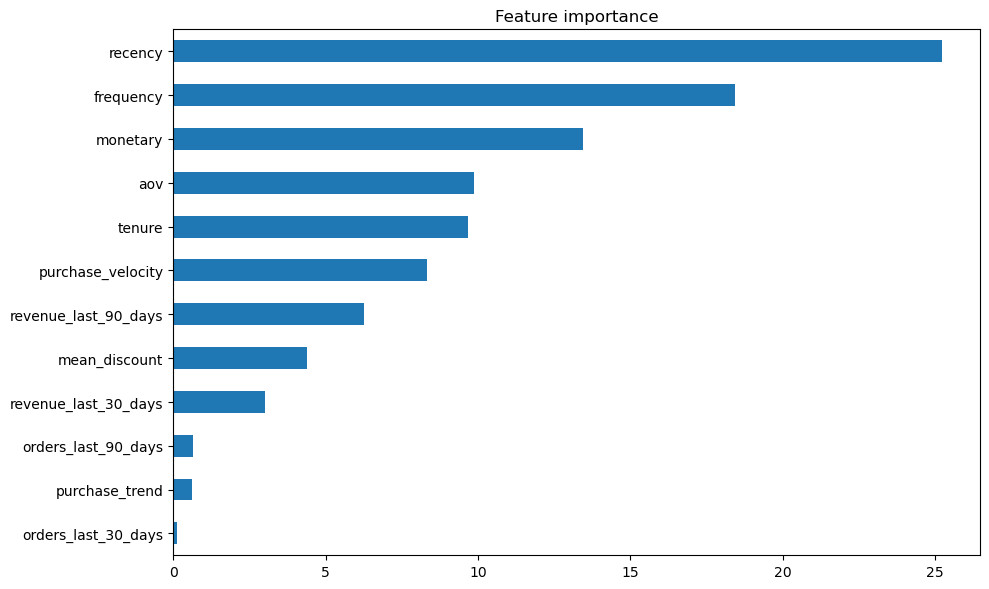

In [52]:
importance.sort_values().plot(kind='barh', figsize=(10,6))
plt.title("Feature importance")
plt.tight_layout()

# Step 10 -  Create Customer Segmentation
- first we have to train the model on 9 months data

In [53]:
customer_df = customer_df.reset_index()
new_test = customer_df.drop('customer_id', axis=1)     # Removing customer id column

In [54]:
# Now we predict on new data but we also have to convert it back in real values

new_pred_log = model.predict(new_test)
new_prediction = np.expm1(new_pred_log)

### Merge the prediction into customer_df

In [55]:
customer_df['predicted_revenue'] = new_prediction
customer_df.head()

,customer_id,recency,frequency,monetary,aov,tenure,revenue_last_30_days,revenue_last_90_days,orders_last_30_days,orders_last_90_days,purchase_velocity,purchase_trend,mean_discount,predicted_revenue
0,C00001,420,3,26120.41,8706.803333,182,0.0,0.00,0.0,0.0,0.0165,0.000000,0.250000,4415.651622
1,C00002,20,34,122072.20,3590.358824,599,805.1,8220.64,1.0,4.0,0.0568,0.097936,0.215294,5287.892940
2,C00003,59,4,9363.40,2340.850000,288,0.0,2127.20,0.0,1.0,0.0139,0.000000,0.252500,6099.877885
3,C00004,539,2,3139.84,1569.920000,66,0.0,0.00,0.0,0.0,0.0303,0.000000,0.375000,5337.462343
4,C00005,51,9,26944.34,2993.815556,446,0.0,646.40,0.0,1.0,0.0202,0.000000,0.146667,6087.601681


## Creating segment

In [56]:
customer_df['segment'] = pd.qcut(customer_df['predicted_revenue'],
                                 q=4,
                                 labels = ["Low Value", "Medium Value", "High Value", "VIP"]
                                )
customer_df.head()                   

,customer_id,recency,frequency,monetary,aov,tenure,revenue_last_30_days,revenue_last_90_days,orders_last_30_days,orders_last_90_days,purchase_velocity,purchase_trend,mean_discount,predicted_revenue,segment
0,C00001,420,3,26120.41,8706.803333,182,0.0,0.00,0.0,0.0,0.0165,0.000000,0.250000,4415.651622,Low Value
1,C00002,20,34,122072.20,3590.358824,599,805.1,8220.64,1.0,4.0,0.0568,0.097936,0.215294,5287.892940,High Value
2,C00003,59,4,9363.40,2340.850000,288,0.0,2127.20,0.0,1.0,0.0139,0.000000,0.252500,6099.877885,VIP
3,C00004,539,2,3139.84,1569.920000,66,0.0,0.00,0.0,0.0,0.0303,0.000000,0.375000,5337.462343,High Value
4,C00005,51,9,26944.34,2993.815556,446,0.0,646.40,0.0,1.0,0.0202,0.000000,0.146667,6087.601681,VIP


In [57]:
# Chechk how many cutomers in eaach segment

customer_df['segment'].value_counts(ascending=False)

segment
Low Value       5129
VIP             4976
Medium Value    4950
High Value      4898
Name: count, dtype: int64

<Axes: title={'center': 'Customer Segment Distribution'}, ylabel='segment'>

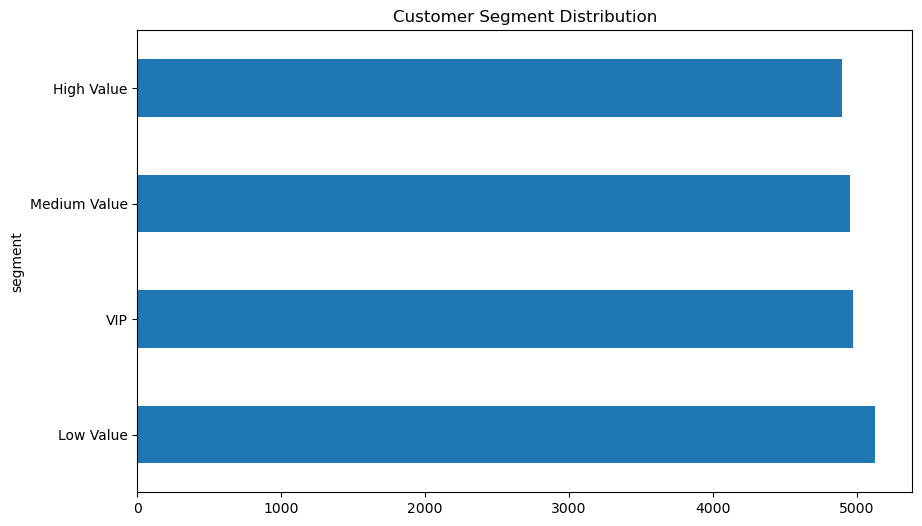

In [58]:
# Plotting graph for segment count

customer_df["segment"].value_counts().plot(kind="barh", figsize =(10,6), title="Customer Segment Distribution")

#### Finding Minimum and Maximum for customer segmentation

In [59]:
segment_summary = customer_df.groupby('segment', observed=True)['predicted_revenue'].agg(['min', 'max', 'count'])
segment_summary

,min,max,count
segment,,,
Low Value,3876.761011,5010.287053,5129
Medium Value,5015.750411,5271.358003,4950
High Value,5271.822195,5620.048417,4898
VIP,5621.515960,296733.831931,4976


Text(0.5, 1.0, 'Customer Segments by Predicted Revenue')

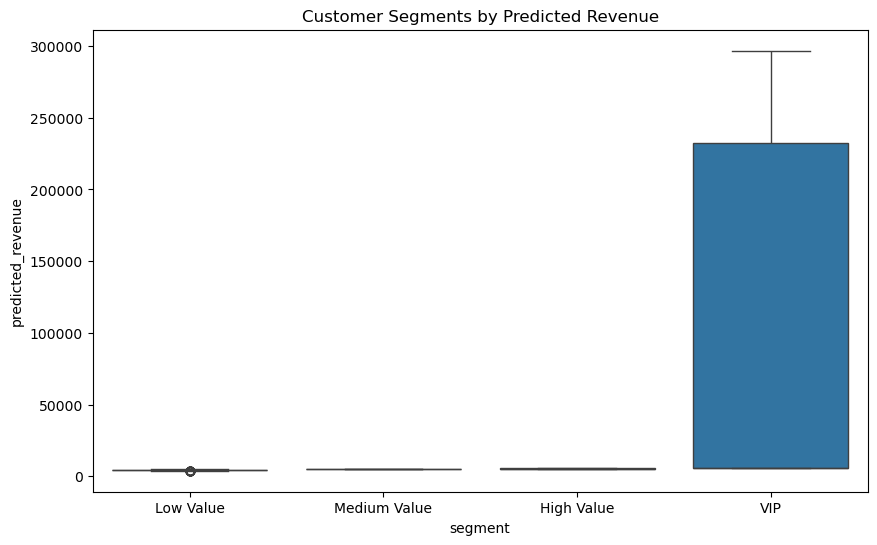

In [60]:
# Ploting Graph to understand 

plt.figure(figsize=(10,6))

sns.boxplot(
    x="segment",
    y="predicted_revenue",
    data=customer_df
)

plt.title("Customer Segments by Predicted Revenue")

- From this we can understand that VIP customers are less then other's still genrating more revenue then other segment's 

C:\Users\Farhan Diwan\AppData\Local\Temp\ipykernel_2512\1771585812.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_revenue = customer_df.groupby("segment")["predicted_revenue"].sum()


Text(0, 0.5, 'Total Predicted Revenue')

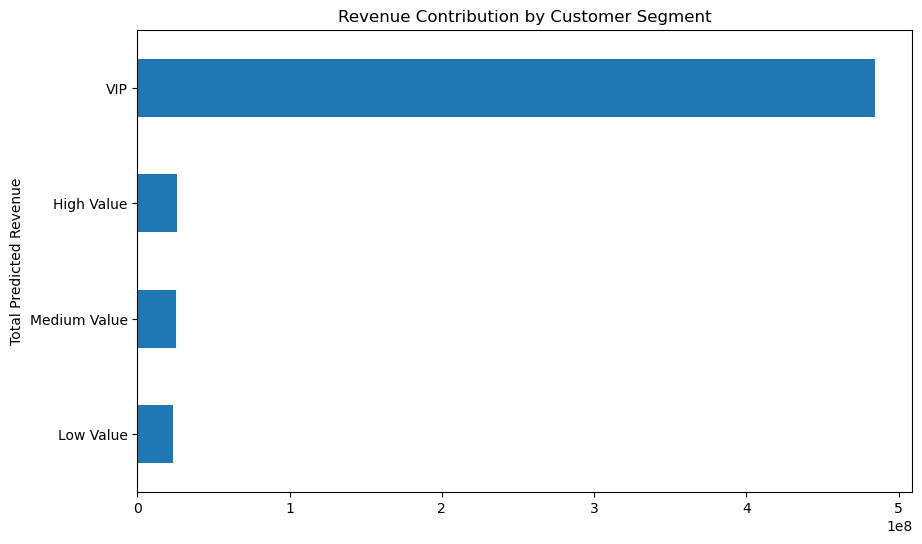

In [61]:
segment_revenue = customer_df.groupby("segment")["predicted_revenue"].sum()

plt.figure(figsize=(10,6))
segment_revenue.plot(kind="barh")
plt.title("Revenue Contribution by Customer Segment")
plt.ylabel("Total Predicted Revenue")

# Step 11 - Offer Strategy 
- Here we make function which recommend the offer based on the segment

In [62]:
# Creating FUNCTION

def offer_strategy(seg):
    if seg == "VIP":
        return "Exclusive VIP Offer"
    elif seg == "High Value":
        return "Loyalty Reward"
    elif seg == "Medium Value":
        return "Personalized Discount"
    elif seg == "Low Value":
        return "Promotion Campaign"

#### Applying to segment column

In [63]:
customer_df['recommend_offer'] = customer_df['segment'].apply(offer_strategy)
customer_df.head()

,customer_id,recency,frequency,monetary,aov,tenure,revenue_last_30_days,revenue_last_90_days,orders_last_30_days,orders_last_90_days,purchase_velocity,purchase_trend,mean_discount,predicted_revenue,segment,recommend_offer
0,C00001,420,3,26120.41,8706.803333,182,0.0,0.00,0.0,0.0,0.0165,0.000000,0.250000,4415.651622,Low Value,Promotion Campaign
1,C00002,20,34,122072.20,3590.358824,599,805.1,8220.64,1.0,4.0,0.0568,0.097936,0.215294,5287.892940,High Value,Loyalty Reward
2,C00003,59,4,9363.40,2340.850000,288,0.0,2127.20,0.0,1.0,0.0139,0.000000,0.252500,6099.877885,VIP,Exclusive VIP Offer
3,C00004,539,2,3139.84,1569.920000,66,0.0,0.00,0.0,0.0,0.0303,0.000000,0.375000,5337.462343,High Value,Loyalty Reward
4,C00005,51,9,26944.34,2993.815556,446,0.0,646.40,0.0,1.0,0.0202,0.000000,0.146667,6087.601681,VIP,Exclusive VIP Offer


In [64]:
# Saving the Output into CSV

customer_df.to_csv('Forecasting_P1.csv', index=False)

# Step 12 - Final Visualization's

In [65]:
# Creating folder to save Figure's
import os

os.makedirs('P1_Figures')

### Revenue Distribution (Customer Value Spread)
- This shows how customer revenue is distributed.
- Many genrate small | high

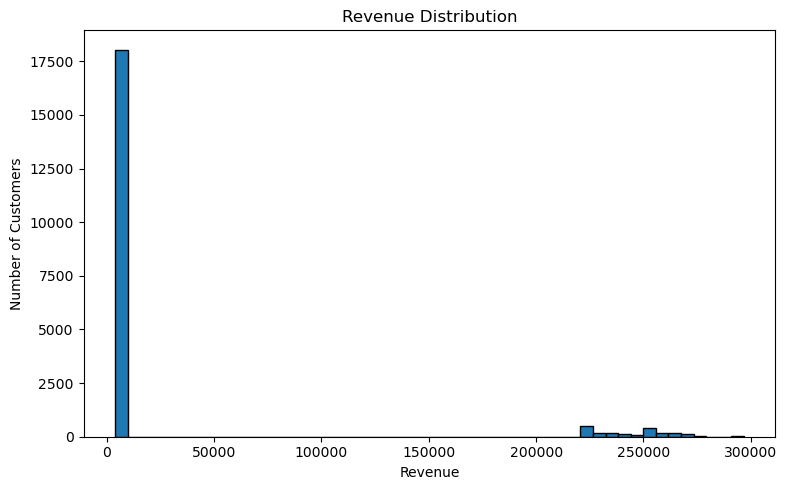

In [70]:
plt.figure(figsize=(8,5))

plt.hist(customer_df['predicted_revenue'], bins=50, edgecolor='black')

plt.xlabel("Revenue")
plt.ylabel("Number of Customers")
plt.title("Revenue Distribution")
plt.tight_layout()

plt.savefig("P1_Figures/revenue_distribution.png", bbox_inches="tight")

### Segment Distribution
- Shows how customers are distributed across segments.

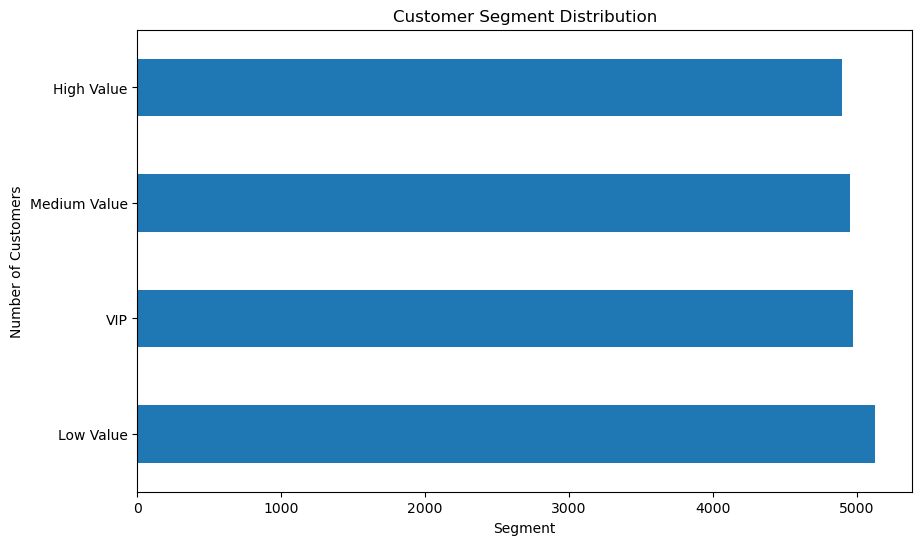

In [67]:
customer_df["segment"].value_counts().plot(kind="barh", figsize =(10,6), title="Customer Segment Distribution")
plt.title("Customer Segment Distribution")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")

plt.savefig("P1_Figures/revenue_distribution.png", bbox_inches="tight")

### Predicted vs Actual Revenue (Model Performance)
- This chart tells how accurate your model predictions are.

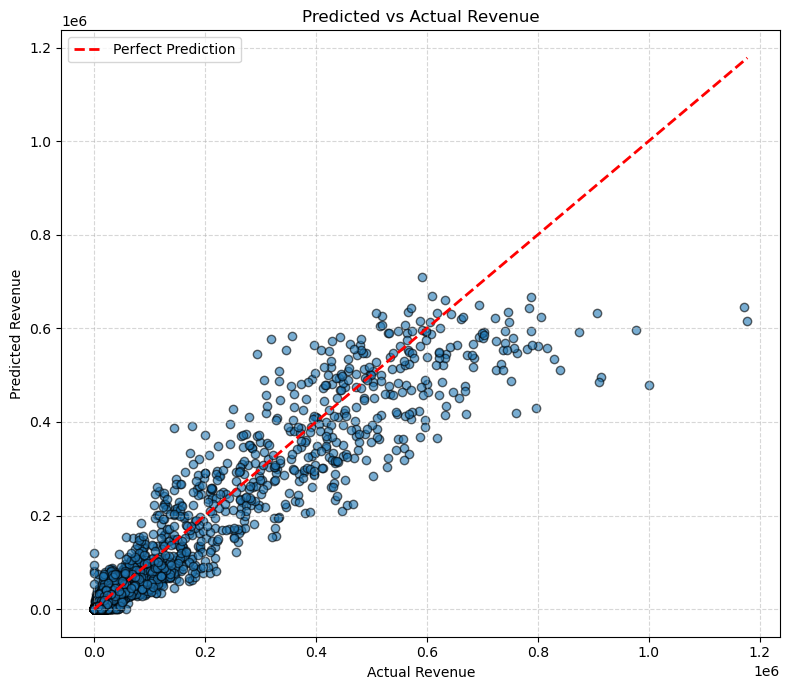

In [68]:
plt.figure(figsize=(8,7))

plt.scatter(
    y_test,
    y_prediction,
    alpha=0.6,
    edgecolor="black"
)

# Perfect prediction line
min_val = min(min(y_test), min(y_prediction))
max_val = max(max(y_test), max(y_prediction))

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="red",
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title("Predicted vs Actual Revenue")
plt.tight_layout()
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

plt.savefig("P1_Figures/revenue_distribution.png", bbox_inches="tight")

In [69]:
print("Model Successfully Created")

Model Successfully Created
